Mejor camino encontrado: ['A', 'B', 'E']
Costo del mejor camino: 4


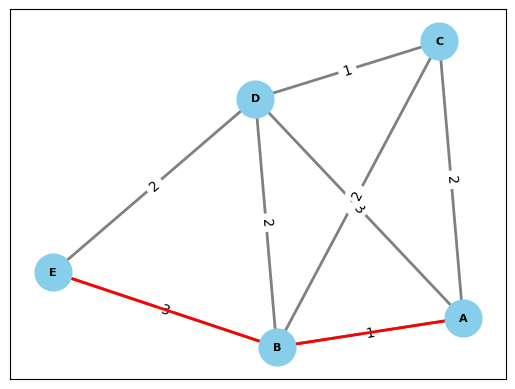

In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt

class ColoniaHormigas:
    def __init__(self, grafo, n_hormigas=10, alfa=1.0, beta=2.0, evaporacion=0.5, Q=1.0):
        self.grafo = grafo
        self.n_hormigas = n_hormigas
        self.alfa = alfa
        self.beta = beta
        self.evaporacion = evaporacion
        self.Q = Q
        self.feromonas = self.inicializar_feromonas()

    def inicializar_feromonas(self):
        feromonas = {}
        for origen in self.grafo:
            for destino in self.grafo[origen]:
                feromonas[(origen, destino)] = 1.0
        return feromonas

    def elegir_siguiente_nodo(self, nodo_actual, camino):
        vecinos = [nodo for nodo in self.grafo[nodo_actual] if nodo not in camino]
        if not vecinos:
            return camino[0]  # Regresar al origen si no hay vecinos no visitados

        probabilidades = self.calcular_probabilidades(nodo_actual, vecinos)
        return random.choices(vecinos, weights=probabilidades)[0]

    def calcular_probabilidades(self, nodo_actual, vecinos):
        probabilidades = []
        for vecino in vecinos:
            # Asegurarse de que la arista esté presente en el diccionario
            arista = (nodo_actual, vecino)
            if arista in self.feromonas:
                feromona = self.feromonas[arista]
                distancia = self.grafo[nodo_actual][vecino]
                probabilidad = feromona**self.alfa * (1 / distancia)**self.beta
                probabilidades.append(probabilidad)
            else:
                # Si la arista no está en el diccionario, asignar una probabilidad mínima
                probabilidades.append(0.0001)
        suma_probabilidades = sum(probabilidades)
        return [p / suma_probabilidades for p in probabilidades]

    def encontrar_caminos(self, origen, destino):
        todos_los_caminos = []
        for _ in range(self.n_hormigas):
            camino = self.generar_camino(origen, destino)
            todos_los_caminos.append((camino, self.calcular_costo_camino(camino)))
        return todos_los_caminos

    def generar_camino(self, origen, destino):
        camino = [origen]
        while camino[-1] != destino:
            siguiente_nodo = self.elegir_siguiente_nodo(camino[-1], camino)
            camino.append(siguiente_nodo)
        return camino

    def calcular_costo_camino(self, camino):
        costo = 0
        for i in range(len(camino) - 1):
            costo += self.grafo[camino[i]][camino[i + 1]]
        return costo

    def actualizar_feromonas(self):
        for clave in self.feromonas:
            self.feromonas[clave] *= (1 - self.evaporacion)
        for camino, costo in self.todas_los_caminos:
            longitud_camino = len(camino)
            for i in range(longitud_camino - 1):
                arista = (camino[i], camino[i + 1])
                self.feromonas[arista] += self.Q / costo

                # Asegurarse de que la arista en la dirección opuesta también tenga una entrada en el diccionario
                arista_inversa = (camino[i + 1], camino[i])
                if arista_inversa not in self.feromonas:
                    self.feromonas[arista_inversa] = 1.0

    def ejecutar(self, origen, destino, iteraciones=1):
        for _ in range(iteraciones):
            self.todas_los_caminos = self.encontrar_caminos(origen, destino)
            self.actualizar_feromonas()
        return min(self.todas_los_caminos, key=lambda x: x[1])
    def visualizar_grafo(self, mejor_camino=None):
        G = nx.Graph(self.grafo)

        pos = nx.spring_layout(G)

        # Dibujar nodos
        nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

        # Dibujar aristas con etiquetas de costos
        edge_labels = {(i, j): str(self.grafo[i][j]) for i, j in G.edges()}
        nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        # Dibujar etiquetas de nodos
        nx.draw_networkx_labels(G, pos, font_size=8, font_color='black', font_weight='bold')

        # Resaltar mejor camino en rojo
        if mejor_camino:
            mejor_camino_edges = [(mejor_camino[i], mejor_camino[i + 1]) for i in range(len(mejor_camino) - 1)]
            nx.draw_networkx_edges(G, pos, edgelist=mejor_camino_edges, edge_color='red', width=2)

        plt.show()


# Ejemplo de uso:
grafo = {
    'A': {'B': 1, 'C': 2, 'D': 3},
    'B': {'A': 1, 'C': 2, 'D': 2, 'E': 3},
    'C': {'A': 2, 'B': 2, 'D': 1},
    'D': {'A': 3, 'B': 2, 'C': 1, 'E': 2},
    'E': {'B': 3, 'D': 2}
}

colonia = ColoniaHormigas(grafo, n_hormigas=10)
mejor_camino, mejor_costo = colonia.ejecutar('A', 'E', iteraciones=1)
#Ejemplo de uso 2:
#grafo = {
 #'A': {'B': 1, 'C': 2, 'D': 3},
 #'B': {'A': 1, 'C': 2, 'D': 2},
 #'C': {'A': 2, 'B': 2, 'D': 1},
 #'D': {'A': 3, 'B': 2, 'C': 1},

#}

#colonia = ColoniaHormigas(grafo, n_hormigas=50)
#mejor_camino, mejor_costo = colonia.ejecutar('A', 'D', iteraciones=100)

print("Mejor camino encontrado:", mejor_camino)
print("Costo del mejor camino:", mejor_costo)

colonia.visualizar_grafo(mejor_camino)